# Initial EDA: Crypto Meme Coin Dashboard

This notebook extends the initial exploration with volatility analysis, coin comparison, and Power BI-ready insights. The goal is to support dashboard storytelling for meme coins and benchmark coins together.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import duckdb
from pathlib import Path

plt.style.use('seaborn-v0_8')
DATA_PATH = Path('../data/interim/master_cleaned.csv')
df = pd.read_csv(DATA_PATH, parse_dates=['date'])
df.head()

,date,coin_id,price,volume,market_cap,daily_return_pct,price_7d_ma,volume_7d_ma
0,2025-04-08,bitcoin,79179.292268,8.290975e+10,1.581408e+12,NaN,NaN,NaN
1,2025-04-09,bitcoin,76329.090356,4.781279e+10,1.515042e+12,-3.599681,NaN,NaN
2,2025-04-10,bitcoin,82622.170295,8.740822e+10,1.640568e+12,8.244668,NaN,NaN
3,2025-04-11,bitcoin,79596.357323,4.121352e+10,1.580023e+12,-3.662229,NaN,NaN
4,2025-04-12,bitcoin,83439.288180,3.981357e+10,1.655869e+12,4.828024,NaN,NaN


In [3]:
df.shape

(1464, 8)

In [4]:
df["coin_id"].value_counts()

coin_id
bitcoin           366
dogwifcoin        366
floki             366
official-trump    366
Name: count, dtype: int64

In [5]:
df["date"].min(), df["date"].max()

(Timestamp('2025-04-08 00:00:00'), Timestamp('2026-04-07 00:00:00'))

In [6]:
print('Rows:', len(df))
print('Columns:', df.shape[1])
print('Coins:', df['coin_id'].nunique())
print('Date range:', df['date'].min(), '->', df['date'].max())
print('Missing values by column:')
print(df.isnull().sum())


Rows: 1464
Columns: 8
Coins: 4
Date range: 2025-04-08 00:00:00 -> 2026-04-07 00:00:00
Missing values by column:
date                 0
coin_id              0
price                0
volume               0
market_cap           0
daily_return_pct     4
price_7d_ma         24
volume_7d_ma        24
dtype: int64


## Volatility

Meme coins show higher volatility, meaning larger price swings and higher risk.  
Bitcoin is more stable with lower daily fluctuations.

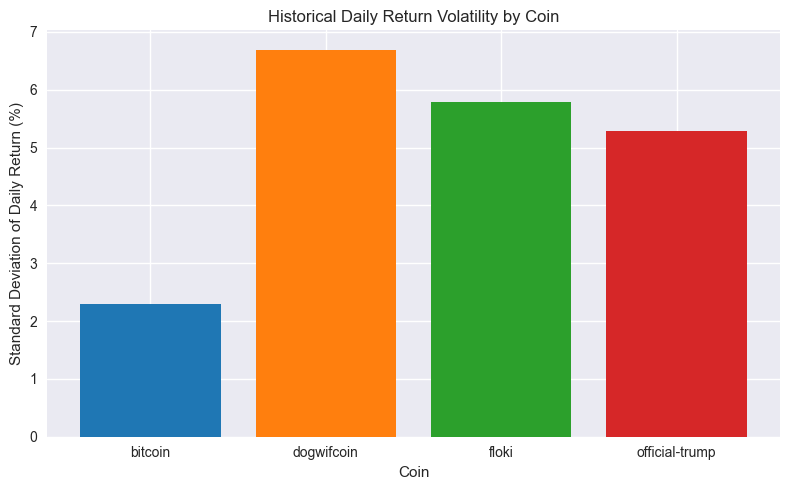

,coin_id,return_volatility
0,bitcoin,2.29
1,dogwifcoin,6.69
2,floki,5.78
3,official-trump,5.28


In [35]:
volatility = df.groupby('coin_id')['daily_return_pct'].std().reset_index()
volatility.columns = ['coin_id', 'return_volatility']
volatility['return_volatility'] = volatility['return_volatility'].round(2)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(volatility['coin_id'], volatility['return_volatility'], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
ax.set_title('Historical Daily Return Volatility by Coin')
ax.set_xlabel('Coin')
ax.set_ylabel('Standard Deviation of Daily Return (%)')
plt.tight_layout()
plt.show()
volatility

## Summary Metrics
Provides an overview of price, volume, returns, and volatility per coin.  
Helps compare overall performance and market behavior.

In [36]:
summary = df.groupby('coin_id').agg(
    avg_price=('price', 'mean'),
    avg_volume=('volume', 'mean'),
    avg_market_cap=('market_cap', 'mean'),
    avg_daily_return=('daily_return_pct', 'mean'),
    volatility_30d=('daily_return_pct', lambda x: x.rolling(30).std().mean()),
).reset_index()
summary['avg_price'] = summary['avg_price'].round(2)
summary['avg_volume'] = summary['avg_volume'].round(0)
summary['avg_market_cap'] = summary['avg_market_cap'].round(0)
summary['avg_daily_return'] = summary['avg_daily_return'].round(2)
summary['volatility_30d'] = summary['volatility_30d'].round(2)
summary

,coin_id,avg_price,avg_volume,avg_market_cap,avg_daily_return,volatility_30d
0,bitcoin,97145.45,4.610623e+10,1.935815e+12,-0.01,2.12
1,dogwifcoin,0.59,2.583377e+08,5.882104e+08,0.04,6.55
2,floki,0.00,1.032185e+08,6.632781e+08,-0.01,5.67
3,official-trump,7.42,4.695064e+08,1.503159e+09,-0.15,4.52


### SQL Aggregation
SQL is used to summarize key metrics per coin.  
Demonstrates ability to query data efficiently using SQL.

In [37]:
query = '''
SELECT
    coin_id,
    COUNT(*) AS observations,
    MIN(date) AS first_date,
    MAX(date) AS last_date,
    AVG(price) AS avg_price,
    AVG(volume) AS avg_volume,
    AVG(market_cap) AS avg_market_cap
FROM df
GROUP BY coin_id
ORDER BY avg_market_cap DESC
'''
coin_compare = duckdb.query(query).to_df()
coin_compare['avg_price'] = coin_compare['avg_price'].round(2)
coin_compare['avg_volume'] = coin_compare['avg_volume'].round(0)
coin_compare['avg_market_cap'] = coin_compare['avg_market_cap'].round(0)
coin_compare

,coin_id,observations,first_date,last_date,avg_price,avg_volume,avg_market_cap
0,bitcoin,366,2025-04-08,2026-04-07,97145.45,4.610623e+10,1.935815e+12
1,official-trump,366,2025-04-08,2026-04-07,7.42,4.695064e+08,1.503159e+09
2,floki,366,2025-04-08,2026-04-07,0.00,1.032185e+08,6.632781e+08
3,dogwifcoin,366,2025-04-08,2026-04-07,0.59,2.583377e+08,5.882104e+08


### Maximum Drawdown
Meme coins show large drops from peak values, indicating high downside risk.  
Bitcoin has smaller drawdowns, showing better stability.m

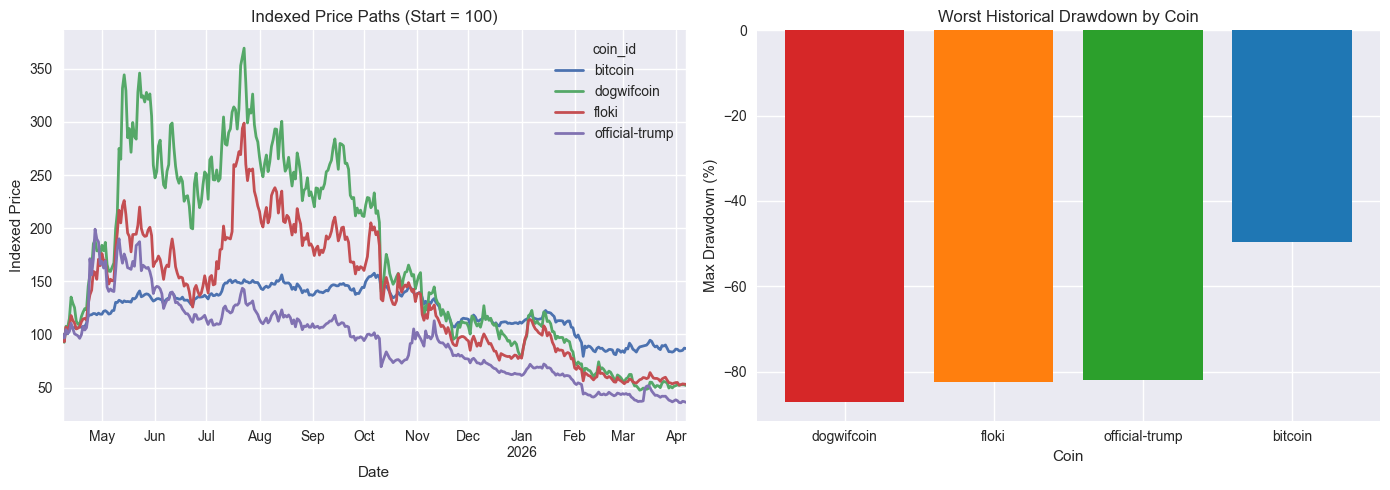

,coin_id,max_drawdown_pct
0,dogwifcoin,-87.14
1,floki,-82.49
2,official-trump,-82.08
3,bitcoin,-49.63


In [38]:
df_daily = (
    df.groupby(['date', 'coin_id'], as_index=False)
    .agg(
        price=('price', 'mean'),
        volume=('volume', 'mean'),
        daily_return_pct=('daily_return_pct', 'mean'),
    )
    .sort_values(['date', 'coin_id'])
)

price_wide = df_daily.pivot(index='date', columns='coin_id', values='price').sort_index()

indexed_price = price_wide.div(price_wide.iloc[0]).mul(100)
running_peak = indexed_price.cummax()
drawdown_pct = (indexed_price / running_peak - 1) * 100

max_drawdown = drawdown_pct.min().sort_values().reset_index()
max_drawdown.columns = ['coin_id', 'max_drawdown_pct']
max_drawdown['max_drawdown_pct'] = max_drawdown['max_drawdown_pct'].round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

indexed_price.plot(ax=axes[0], linewidth=2)
axes[0].set_title('Indexed Price Paths (Start = 100)')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Indexed Price')

axes[1].bar(max_drawdown['coin_id'], max_drawdown['max_drawdown_pct'], color=['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4'])
axes[1].set_title('Worst Historical Drawdown by Coin')
axes[1].set_xlabel('Coin')
axes[1].set_ylabel('Max Drawdown (%)')

plt.tight_layout()
plt.show()

max_drawdown

### Risk vs Return
Meme coins have high risk but do not consistently provide higher returns.  
Bitcoin offers a more balanced and stable risk-return profile.

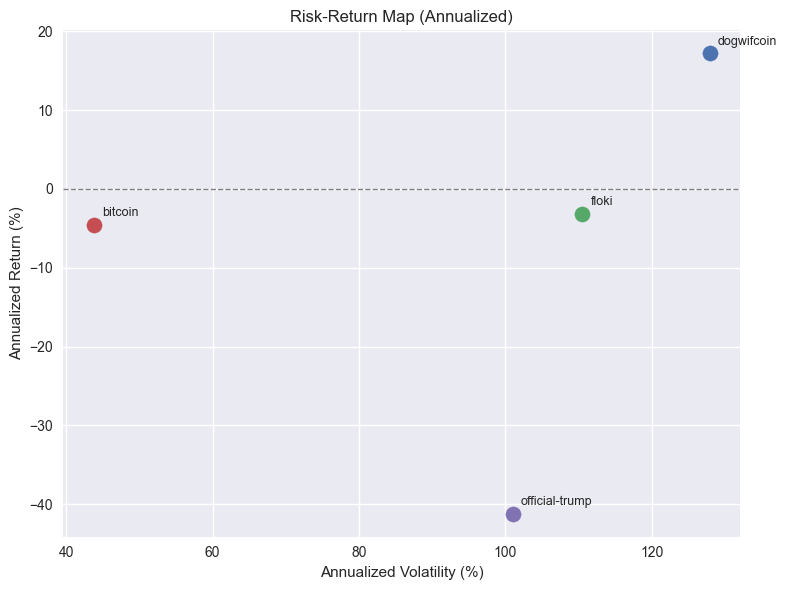

,coin_id,annual_return_pct,annual_volatility_pct,return_per_unit_risk
0,dogwifcoin,17.21,127.94,0.13
1,floki,-3.15,110.51,-0.03
2,bitcoin,-4.53,43.74,-0.10
3,official-trump,-41.22,100.99,-0.41


In [39]:
returns_wide = df_daily.pivot(index='date', columns='coin_id', values='daily_return_pct').sort_index()

returns_dec = returns_wide / 100

mean_daily = returns_dec.mean()
std_daily = returns_dec.std()

annual_return_pct = ((1 + mean_daily).clip(lower=1e-6) ** 365 - 1) * 100
annual_vol_pct = std_daily * (365 ** 0.5) * 100

sharpe_like = annual_return_pct / annual_vol_pct

risk_return = pd.DataFrame({
    'annual_return_pct': annual_return_pct,
    'annual_volatility_pct': annual_vol_pct,
    'return_per_unit_risk': sharpe_like,
}).round(2).sort_values('return_per_unit_risk', ascending=False).reset_index()

fig, ax = plt.subplots(figsize=(8, 6))
for _, row in risk_return.iterrows():
    ax.scatter(row['annual_volatility_pct'], row['annual_return_pct'], s=120)
    ax.annotate(row['coin_id'], (row['annual_volatility_pct'], row['annual_return_pct']),
                textcoords='offset points', xytext=(6, 6), fontsize=9)

ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Risk-Return Map (Annualized)')
ax.set_xlabel('Annualized Volatility (%)')
ax.set_ylabel('Annualized Return (%)')

plt.tight_layout()
plt.show()

risk_return

### Correlation
Meme coins move similarly, reducing diversification benefits.  
Bitcoin is less correlated and provides better portfolio balance.

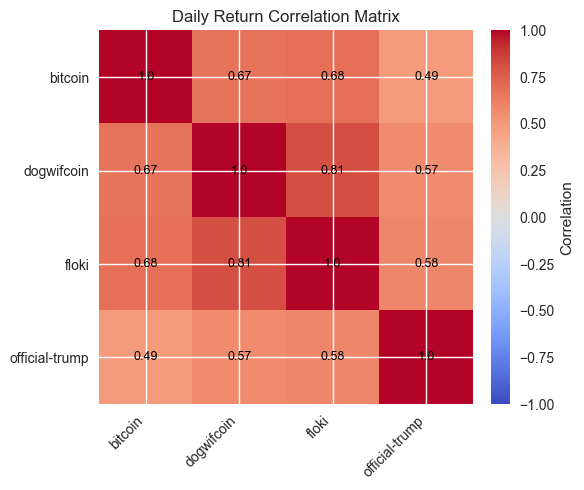

coin_id,bitcoin,dogwifcoin,floki,official-trump
coin_id,,,,
bitcoin,1.00,0.67,0.68,0.49
dogwifcoin,0.67,1.00,0.81,0.57
floki,0.68,0.81,1.00,0.58
official-trump,0.49,0.57,0.58,1.00


In [40]:
corr = returns_wide.corr().round(2)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.index)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, corr.iloc[i, j], ha='center', va='center', color='black', fontsize=9)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Correlation')
ax.set_title('Daily Return Correlation Matrix')

plt.tight_layout()
plt.show()

corr

### Volume Spikes
Volume spikes sometimes lead to gains but often result in losses.  
This suggests hype-driven behavior and potential market inefficiencies.

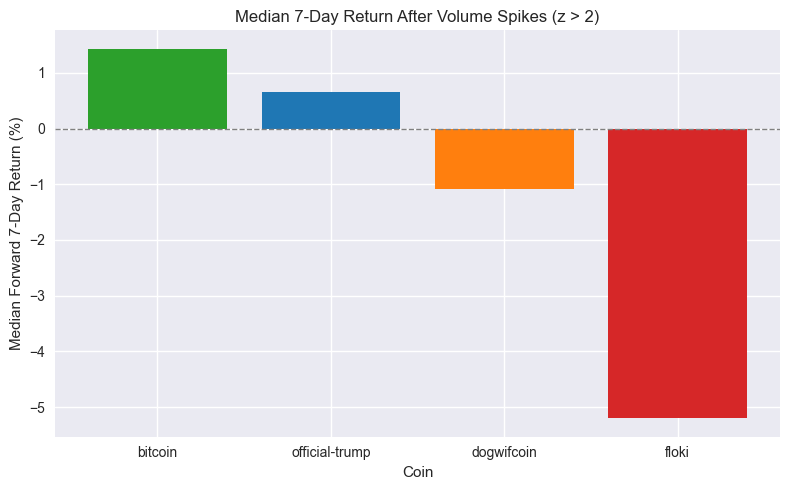

,coin_id,volume_spike_events,median_7d_return_after_spike_pct,mean_7d_return_after_spike_pct
0,bitcoin,15,1.43,1.39
3,official-trump,20,0.65,-2.27
1,dogwifcoin,17,-1.08,1.69
2,floki,19,-5.20,-2.88


In [41]:
volume_wide = df_daily.pivot(index='date', columns='coin_id', values='volume').sort_index()
future_7d_return = (price_wide.shift(-7) / price_wide - 1) * 100

vol_mean_30 = volume_wide.rolling(30).mean()
vol_std_30 = volume_wide.rolling(30).std()
vol_zscore = (volume_wide - vol_mean_30) / vol_std_30

event_mask = vol_zscore > 2
event_summary = []

for coin in event_mask.columns:
    mask = event_mask[coin].fillna(False)
    coin_future = future_7d_return.loc[mask, coin].dropna()
    event_summary.append({
        'coin_id': coin,
        'volume_spike_events': int(mask.sum()),
        'median_7d_return_after_spike_pct': coin_future.median() if len(coin_future) else float('nan'),
        'mean_7d_return_after_spike_pct': coin_future.mean() if len(coin_future) else float('nan')
    })

event_summary_df = pd.DataFrame(event_summary).round(2).sort_values('median_7d_return_after_spike_pct', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(event_summary_df['coin_id'], event_summary_df['median_7d_return_after_spike_pct'],
       color=['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728'])

ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Median 7-Day Return After Volume Spikes (z > 2)')
ax.set_xlabel('Coin')
ax.set_ylabel('Median Forward 7-Day Return (%)')

plt.tight_layout()
plt.show()

event_summary_df